# 02 - Feature Building (Decision-Boundary Dataset)

Implements spec Sections 5–8, especially the staged pipeline in Section 7A and checkpoints in Section 8A.

Outputs:
- `data/model_dataset/dataset.parquet` (COMPLETE dataset; no splitting here)
- `data/model_dataset/feature_list.json` (ordered model input columns only)
- `data/model_dataset/dataset_metadata.json`


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd

# Resolve repo root robustly
ROOT = Path.cwd()
if not (ROOT / 'docs' / 'MINIMAL_PROJECT_SPEC_v2.md').exists():
    if (ROOT.parent / 'docs' / 'MINIMAL_PROJECT_SPEC_v2.md').exists():
        ROOT = ROOT.parent
    else:
        raise RuntimeError('Could not locate repo root (docs/MINIMAL_PROJECT_SPEC_v2.md not found).')

sys.path.insert(0, str(ROOT))
from src import utils

RAW_PARQUET = ROOT / 'data' / 'raw_data' / 'klines_1m.parquet'
OUT_DIR = ROOT / 'data' / 'model_dataset'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('RAW_PARQUET:', RAW_PARQUET)
print('OUT_DIR:', OUT_DIR)


ROOT: c:\Users\vitil\OneDrive\Desktop\barrier_classifier
RAW_PARQUET: c:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\raw_data\klines_1m.parquet
OUT_DIR: c:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset


In [2]:
# STAGE 0: Load raw data (output of notebook 01)
if not RAW_PARQUET.exists():
    raise RuntimeError('Missing data/raw_data/klines_1m.parquet. Run 01_data_download.ipynb first.')

df_raw = pd.read_parquet(RAW_PARQUET)
df_raw = df_raw.sort_index()
utils.assert_index_is_utc_datetime_index(df_raw, context='02_feature_building: df_raw')

print('Raw rows:', len(df_raw))
print('Raw range:', df_raw.index.min(), 'to', df_raw.index.max())
display(df_raw.head())


Raw rows: 525600
Raw range: 2025-01-01 00:01:00+00:00 to 2026-01-01 00:00:00+00:00


,open,high,low,close,volume,quote_volume,num_trades,taker_buy_base,taker_buy_quote
2025-01-01 00:01:00+00:00,93576.00,93610.93,93537.50,93610.93,8.21827,7.689788e+05,2631,3.95157,369757.326529
2025-01-01 00:02:00+00:00,93610.93,93652.00,93606.20,93652.00,12.14029,1.136551e+06,1273,4.08887,382791.500172
2025-01-01 00:03:00+00:00,93652.00,93702.15,93635.98,93702.15,11.60597,1.087101e+06,1095,5.86840,549682.868570
2025-01-01 00:04:00+00:00,93702.14,93702.15,93654.48,93677.98,8.72958,8.177203e+05,1461,2.48203,232486.113080
2025-01-01 00:05:00+00:00,93677.98,93677.99,93659.92,93661.20,5.24749,4.915570e+05,988,0.48880,45786.251963


In [3]:
# STAGE 1: Base series (per-bar)
df = df_raw.copy()
df = utils.compute_base_series(df)
utils.checkpoint_base_series(df)

print('Columns after base series:', len(df.columns))


OK: Base series validation passed
Columns after base series: 26


In [4]:
# STAGE 2: Tier-1 rolling features (no dependencies)
df = utils.compute_lag_features(df, utils.LAGS_F)
df = utils.compute_rolling_stats(df, utils.WINDOWS_B)
df = utils.compute_quantile_features(df, utils.WINDOWS_BPLUS)
df = utils.compute_volatility_ohlc(df, utils.WINDOWS_VOL_OHLC)

# Optional: compute RS-only windows needed for VOL_PAIRS but not present in WINDOWS_VOL_OHLC
_extra_rs = sorted({w for pair in utils.VOL_PAIRS for w in pair} - set(utils.WINDOWS_VOL_OHLC))
if _extra_rs:
    df = utils.compute_volatility_rs_only(df, _extra_rs)

df = utils.compute_candle_geometry(df, utils.WINDOWS_CANDLE_ROLL, utils.WINDOWS_BREAKOUT)
df = utils.compute_trend_momentum(df, utils.WINDOWS_LOGP_Z, utils.WINDOWS_RSI)
df = utils.compute_activity_flow(df, [60, 120, 240])
df = utils.compute_correlations(df, utils.WINDOWS_CORR)
df = utils.compute_permutation_entropy(df, utils.WINDOWS_PENTROPY, m=3, tau=1)
df = utils.compute_event_features(df)
df = utils.compute_data_quality_flags(df)
df = utils.compute_seasonality(df)

print('Columns after Tier-1:', len(df.columns))


Columns after Tier-1: 962


In [5]:
# ============================================================
# STAGE 2.5: Derivatives Base Series and Features (Appendix E)
# ============================================================

if utils.ENABLE_DERIVATIVES_FEATURES:
    DERIV_DIR = ROOT / utils.DERIVATIVES_RAW_DIR

    df_fut = pd.read_parquet(DERIV_DIR / 'futures_klines_1m.parquet').sort_index()
    df_funding = pd.read_parquet(DERIV_DIR / 'funding_rate_1m.parquet').sort_index()
    df_metrics = pd.read_parquet(DERIV_DIR / 'futures_metrics_1m.parquet').sort_index()
    df_eoh = pd.read_parquet(DERIV_DIR / 'eoh_summary_1m.parquet').sort_index()
    df_bvol = pd.read_parquet(DERIV_DIR / 'bvol_index_1m.parquet').sort_index()

    df = df.join(
        df_fut[['close', 'volume', 'quote_volume', 'taker_buy_base', 'num_trades']].rename(
            columns={
                'close': 'close_fut',
                'volume': 'volume_fut',
                'quote_volume': 'quote_volume_fut',
                'taker_buy_base': 'taker_buy_base_fut',
                'num_trades': 'num_trades_fut',
            }
        ),
        how='left',
    )
    df = df.join(df_funding[['funding_rate']], how='left')
    df = df.join(df_metrics[['oi_usd']], how='left')
    df = df.join(
        df_eoh[
            ['opt_oi', 'put_open_interest', 'call_open_interest', 'opt_volume', 'put_volume', 'call_volume']
        ],
        how='left',
    )
    df = df.join(df_bvol[['bvol']], how='left')

    df = utils.compute_derivatives_base_series(df)
    df = utils.compute_basis_features(df, utils.WINDOWS_BASIS)
    df = utils.compute_flow_features(df, utils.WINDOWS_FLOW_CSUM)
    df = utils.compute_oi_features(df, utils.WINDOWS_OI_CHG)
    df = utils.compute_funding_features(df, utils.WINDOWS_FUNDING)
    df = utils.compute_options_features(df, utils.WINDOWS_OPTIONS)
    df = utils.compute_vol_index_features(df, utils.WINDOWS_VOL_IDX)

    utils.checkpoint_derivatives_features(df)

    print('Columns after derivatives:', len(df.columns))


OK: Derivatives features validation passed
Columns after derivatives: 1017


In [6]:
# STAGE 3: Tier-2 rolling features (depend on Tier-1)
df = utils.compute_volatility_decomposition(df, utils.WINDOWS_VOL_DECOMP)
df = utils.compute_excursion_features(df, utils.WINDOWS_EXCURSION, utils.WINDOWS_MAXRET)
df = utils.compute_enhanced_liquidity(df, utils.WINDOWS_LIQ_AMIHUD, utils.WINDOWS_LIQ_RPV, utils.WINDOWS_OFI_IMPULSE)

print('Columns after Tier-2:', len(df.columns))


Columns after Tier-2: 1212


In [7]:
# STAGE 4: Decision boundary sampling (every M bars)
df_boundaries = df.iloc[::utils.M].copy().reset_index()
if 'ts' not in df_boundaries.columns:
    if 'index' in df_boundaries.columns:
        df_boundaries = df_boundaries.rename(columns={'index': 'ts'})
    else:
        raise ValueError("Expected 'ts' column after reset_index()")
df_boundaries['k'] = np.arange(len(df_boundaries), dtype=int)
utils.checkpoint_boundaries(df_boundaries, df_raw, utils.M)

print('Boundaries:', len(df_boundaries))
display(df_boundaries[['ts','k']].head())


OK: Decision boundary validation passed
Boundaries: 26280


,ts,k
0,2025-01-01 00:01:00+00:00,0
1,2025-01-01 00:21:00+00:00,1
2,2025-01-01 00:41:00+00:00,2
3,2025-01-01 01:01:00+00:00,3
4,2025-01-01 01:21:00+00:00,4


In [8]:
# Drop raw + base series columns from boundary dataset (keep only engineered features + identifiers).
# This enforces the dataset contract: model inputs come from feature_list.json only.
RAW_COLS = [
    'open','high','low','close','volume','quote_volume','num_trades','taker_buy_base','taker_buy_quote'
]
BASE_COLS = [
    'p','r','rho','r_oc','g','logvol','logtrades','logquotevol',
    'b','ofi','clv','bodyfrac','wickup','wickdn','vwap','vwapdev','qpertrade'
]
DERIV_BASE_COLS = [
    'close_fut','volume_fut','quote_volume_fut','taker_buy_base_fut','num_trades_fut',
    'funding_rate','oi_usd','opt_oi','put_open_interest','call_open_interest',
    'opt_volume','put_volume','call_volume','bvol',
    'basis_abs','basis_pct','tb_ratio_fut','net_vol_fut','pcr_oi','pcr_vol',
]

drop_cols = [c for c in (RAW_COLS + BASE_COLS + DERIV_BASE_COLS) if c in df_boundaries.columns]
df_boundaries = df_boundaries.drop(columns=drop_cols)

print('Columns after dropping raw/base:', len(df_boundaries.columns))


Columns after dropping raw/base: 1168


In [9]:
# STAGE 5: Label construction (uses FUTURE bars in df_raw)
df_boundaries = utils.construct_labels(df_boundaries, df_raw, utils.M, utils.ETA, utils.C)
if float(df_boundaries['phi'].iloc[0]) != float(utils.PHI):
    raise ValueError('Label phi mismatch: construct_labels phi != config PHI')
utils.checkpoint_labels(df_boundaries, phi=utils.PHI)

print('Label base rate (incl NaNs for last boundary):', float(df_boundaries['y'].mean()))


OK: Label validation passed
Label base rate (incl NaNs for last boundary): 0.1798013623045017


In [10]:
# STAGE 6: Past-target features (matured labels only; MUST be shifted)
df_boundaries = utils.compute_past_target_features(df_boundaries, utils.WINDOWS_H, utils.HITRATE_WINDOWS_H)

# Sanity: hit__prev at k=0 is NaN
assert pd.isna(df_boundaries['hit__prev__h__w0'].iloc[0])
print('Past-target features added')


Past-target features added


In [11]:
# STAGE 7: Barrier-aware features + constants
df_boundaries = utils.compute_barrier_aware_features(df_boundaries, utils.WINDOWS_BARRIER, utils.PHI, utils.M, utils.VOL_PAIRS)

print('Barrier-aware features added')


Barrier-aware features added


In [12]:
# STAGE 8: Block-level features
df_boundaries = utils.compute_block_features(df_boundaries, df_raw, utils.M, utils.WINDOWS_H)
print('Block features added')


Block features added


In [13]:
# STAGE 9: Warmup trimming + drop last NaN label
df_final = df_boundaries[df_boundaries['k'] >= utils.K_WARMUP].copy()
df_final = df_final[df_final['y'].notna()].copy()
utils.checkpoint_warmup_trimmed(df_final, utils.K_WARMUP)

print('Final rows after trimming:', len(df_final))
print('Final range:', df_final['ts'].min(), 'to', df_final['ts'].max())


OK: Warmup trimming validation passed
Final rows after trimming: 25271
Final range: 2025-01-15 00:01:00+00:00 to 2025-12-31 23:21:00+00:00


In [14]:
# STAGE 10: Undefined flags + imputation
LABEL_AUX_COLS = ['m_k', 'tau_k', 'phi']
WEIGHT_COLS = ['w_dist', 'w_time', 'weight']

DERIV_BASE_COLS = [
    'close_fut','volume_fut','quote_volume_fut','taker_buy_base_fut','num_trades_fut',
    'funding_rate','oi_usd','opt_oi','put_open_interest','call_open_interest',
    'opt_volume','put_volume','call_volume','bvol',
    'basis_abs','basis_pct','tb_ratio_fut','net_vol_fut','pcr_oi','pcr_vol',
]
NON_FEATURE_COLS = ['k', 'ts', 'y'] + LABEL_AUX_COLS + WEIGHT_COLS + DERIV_BASE_COLS

feature_cols = [c for c in df_final.columns if c not in NON_FEATURE_COLS]

P_HIT_PRIOR = 0.5
df_final, undef_cols = utils.create_undef_flags_and_impute(
    df_final,
    feature_cols=feature_cols,
    p_hit_prior=P_HIT_PRIOR,
    cap_h_blocks=max(utils.WINDOWS_H),
)
feature_list = feature_cols + undef_cols

utils.checkpoint_final_dataset(df_final, feature_list)

print('Feature columns:', len(feature_cols))
print('Undef flags:', len(undef_cols))
print('Total model inputs:', len(feature_list))


c:\Users\vitil\OneDrive\Desktop\barrier_classifier\src\utils.py:2861: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out[col] = out[col].fillna(impute_value)
c:\Users\vitil\OneDrive\Desktop\barrier_classifier\src\utils.py:2861: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  out[col] = out[col].fillna(impute_value)
c:\Users\vitil\OneDrive\Desktop\barrier_classifier\src\utils.py:2861: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To o

OK: Final dataset validation passed
  Rows: 25,271
  Features: 1250
  Base rate: 0.179
  Date range: 2025-01-15 00:01:00+00:00 to 2025-12-31 23:21:00+00:00
Feature columns: 1236
Undef flags: 14
Total model inputs: 1250


In [15]:
# STAGE W: Observation weighting (optional)
WEIGHT_USE_DIST = utils.WEIGHT_USE_BARRIER_DISTANCE
WEIGHT_USE_TIME = utils.WEIGHT_USE_TIME_DISCOUNT
WEIGHT_W_MAX = utils.WEIGHT_DIST_W_MAX
WEIGHT_Q_TAIL = utils.WEIGHT_DIST_Q_TAIL
WEIGHT_TIME_R = utils.WEIGHT_TIME_R
WEIGHT_TIME_DELTA = utils.WEIGHT_TIME_DELTA
WEIGHT_NORMALIZE = utils.WEIGHT_NORMALIZE

print('Weighting config:')
print(f'  barrier_distance: enabled={WEIGHT_USE_DIST}, w_max={WEIGHT_W_MAX}, q_tail={WEIGHT_Q_TAIL}')
print(f'  time_discount: enabled={WEIGHT_USE_TIME}, r={WEIGHT_TIME_R}, delta={WEIGHT_TIME_DELTA}')
print(f'  normalize: {WEIGHT_NORMALIZE}')

m_k = df_final['m_k'].to_numpy()
phi = float(df_final['phi'].iloc[0])
k_index = df_final['k'].to_numpy()

w_combined, w_dist, w_time, weight_info = utils.compute_training_weights(
    m_k=m_k,
    phi=phi,
    use_dist=WEIGHT_USE_DIST,
    use_time=WEIGHT_USE_TIME,
    w_max=WEIGHT_W_MAX,
    q_tail=WEIGHT_Q_TAIL,
    r=WEIGHT_TIME_R,
    delta=WEIGHT_TIME_DELTA,
    k_index=k_index,
    normalize=WEIGHT_NORMALIZE,
)

utils.checkpoint_weights(w_combined, w_dist, w_time, weight_info)

df_final['w_dist'] = w_dist
df_final['w_time'] = w_time
df_final['weight'] = w_combined

n_capped = weight_info['barrier_distance']['n_capped']
oldest_weight = weight_info['time_discount']['oldest_weight']
effective_n = weight_info['combined']['effective_n']

print()
print(f'Barrier-distance: range [{w_dist.min():.4f}, {w_dist.max():.4f}], capped {n_capped:,}')
print(f'Time-discount: oldest weight = {oldest_weight:.6f}')
print(f'Combined: range [{w_combined.min():.6f}, {w_combined.max():.4f}], mean = {w_combined.mean():.4f}')
print(f'Effective N: {effective_n:,.0f} / {len(w_combined):,}')


Weighting config:
  barrier_distance: enabled=True, w_max=5.0, q_tail=0.001
  time_discount: enabled=False, r=0.0, delta=0.99999
  normalize: False
OK: Weight validation passed

Barrier-distance: range [1.0000, 5.0000], capped 21
Time-discount: oldest weight = 1.000000
Combined: range [1.000000, 5.0000], mean = 1.6966
Effective N: 22,823 / 25,271


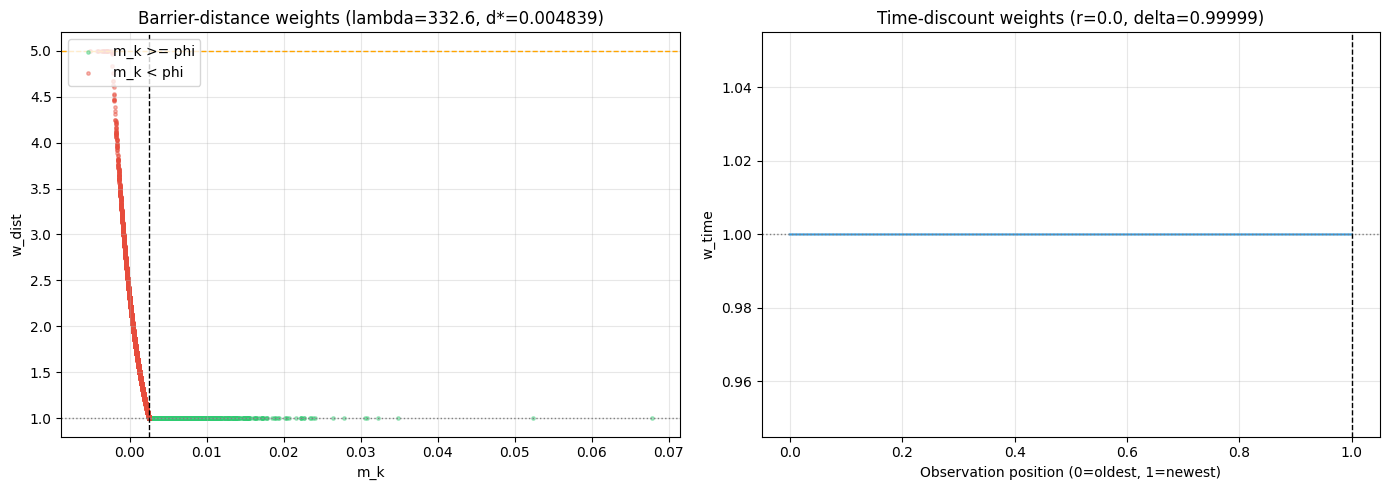

In [16]:
# STAGE W.2: Weight profiles
import matplotlib.pyplot as plt

fig_profiles = utils.plot_weight_profiles(
    m_k=m_k,
    phi=phi,
    w_dist=w_dist,
    w_time=w_time,
    k_index=k_index,
    info=weight_info,
)
plt.show()

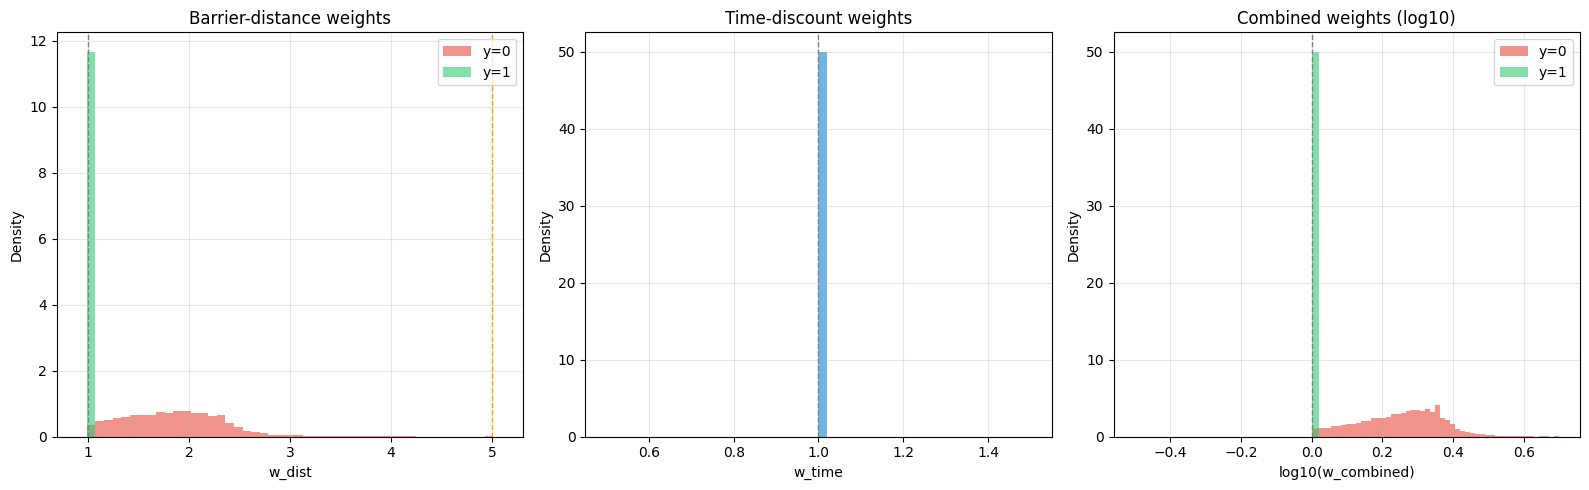

In [17]:
# STAGE W.3: Weight distributions
import matplotlib.pyplot as plt

y = df_final['y'].to_numpy()
fig_dists = utils.plot_weight_distributions(
    w_dist=w_dist,
    w_time=w_time,
    w_combined=w_combined,
    y=y,
    info=weight_info,
)
plt.show()


In [18]:
# STAGE 11: Save complete dataset + metadata + feature list
dataset_path = OUT_DIR / 'dataset.parquet'
feature_list_path = OUT_DIR / 'feature_list.json'
metadata_path = OUT_DIR / 'dataset_metadata.json'

df_final.to_parquet(dataset_path, index=False)
utils.save_feature_list(str(feature_list_path), feature_list)

metadata = {
    'SYMBOL': utils.SYMBOL,
    'INTERVAL': utils.INTERVAL,
    'START_YEAR': utils.START_YEAR,
    'START_MONTH': utils.START_MONTH,
    'END_YEAR': utils.END_YEAR,
    'END_MONTH': utils.END_MONTH,
    'M': utils.M,
    'ETA': utils.ETA,
    'C': utils.C,
    'PHI': utils.PHI,
    'EPS': utils.EPS,
    'WINDOWS_F': utils.WINDOWS_F,
    'LAGS_F': utils.LAGS_F,
    'WINDOWS_H': utils.WINDOWS_H,
    'VOL_PAIRS': utils.VOL_PAIRS,
    'N_WARMUP': utils.N_WARMUP,
    'K_WARMUP': utils.K_WARMUP,
    'label_aux_cols': LABEL_AUX_COLS,
    'non_feature_cols': NON_FEATURE_COLS,
    'n_rows': int(len(df_final)),
    'date_range': [str(df_final['ts'].min()), str(df_final['ts'].max())],
    'feature_count': int(len(feature_list)),
    'weight_cols': WEIGHT_COLS,
    'weighting': weight_info if 'weight_info' in globals() else None,
}
utils.save_metadata(str(metadata_path), metadata)

print('Wrote:', dataset_path)
print('Wrote:', feature_list_path)
print('Wrote:', metadata_path)


Wrote: c:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\dataset.parquet
Wrote: c:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\feature_list.json
Wrote: c:\Users\vitil\OneDrive\Desktop\barrier_classifier\data\model_dataset\dataset_metadata.json


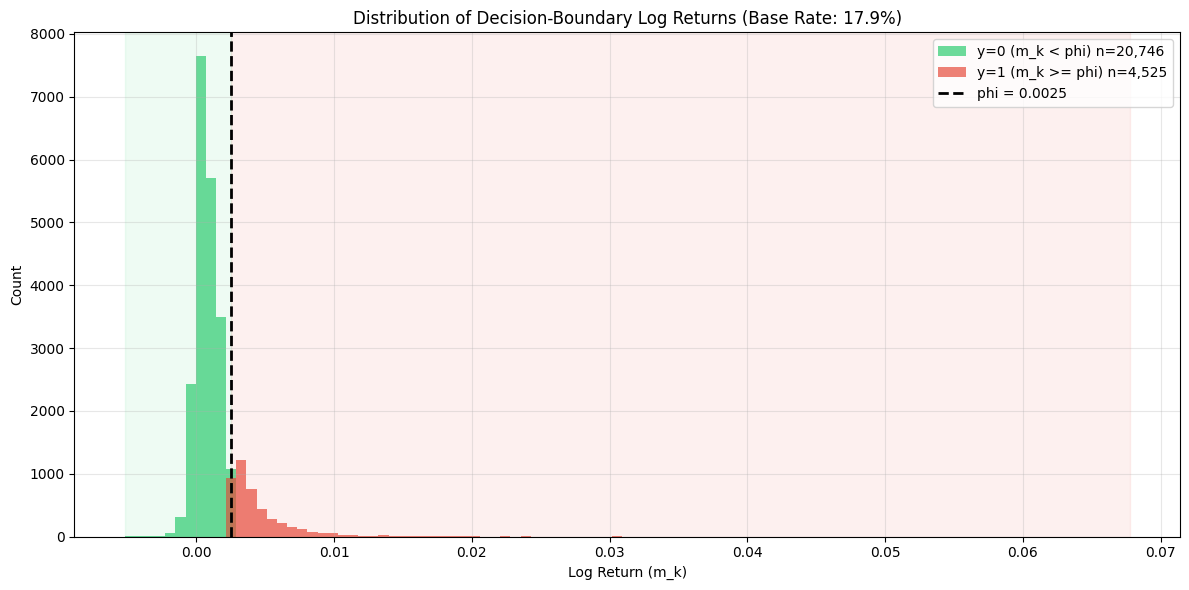

Target threshold (phi): 0.0025
m_k range: [-0.0052, 0.0678]
m_k mean: 0.001452, std: 0.002080
Positive class: 4,525 (17.91%)


In [19]:
# VISUALIZATION 1: Distribution of log returns (m_k) by target class
import matplotlib.pyplot as plt
import numpy as np

m_k = df_final['m_k'].to_numpy()
y = df_final['y'].to_numpy()
phi = float(df_final['phi'].iloc[0])

bins = np.linspace(m_k.min(), m_k.max(), 100)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(
    m_k[y == 0],
    bins=bins,
    alpha=0.7,
    color='#2ecc71',
    label=f'y=0 (m_k < phi) n={int((y == 0).sum()):,}',
    edgecolor='none',
)
ax.hist(
    m_k[y == 1],
    bins=bins,
    alpha=0.7,
    color='#e74c3c',
    label=f'y=1 (m_k >= phi) n={int((y == 1).sum()):,}',
    edgecolor='none',
)
ax.axvline(phi, color='black', linestyle='--', linewidth=2, label=f'phi = {phi:.4f}')

ax.axvspan(m_k.min(), phi, alpha=0.08, color='#2ecc71')
ax.axvspan(phi, m_k.max(), alpha=0.08, color='#e74c3c')

ax.set_xlabel('Log Return (m_k)')
ax.set_ylabel('Count')
ax.set_title(
    f'Distribution of Decision-Boundary Log Returns (Base Rate: {y.mean():.1%})'
)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Target threshold (phi): {phi:.4f}")
print(f"m_k range: [{m_k.min():.4f}, {m_k.max():.4f}]")
print(f"m_k mean: {m_k.mean():.6f}, std: {m_k.std():.6f}")
print(f"Positive class: {(y == 1).sum():,} ({y.mean():.2%})")


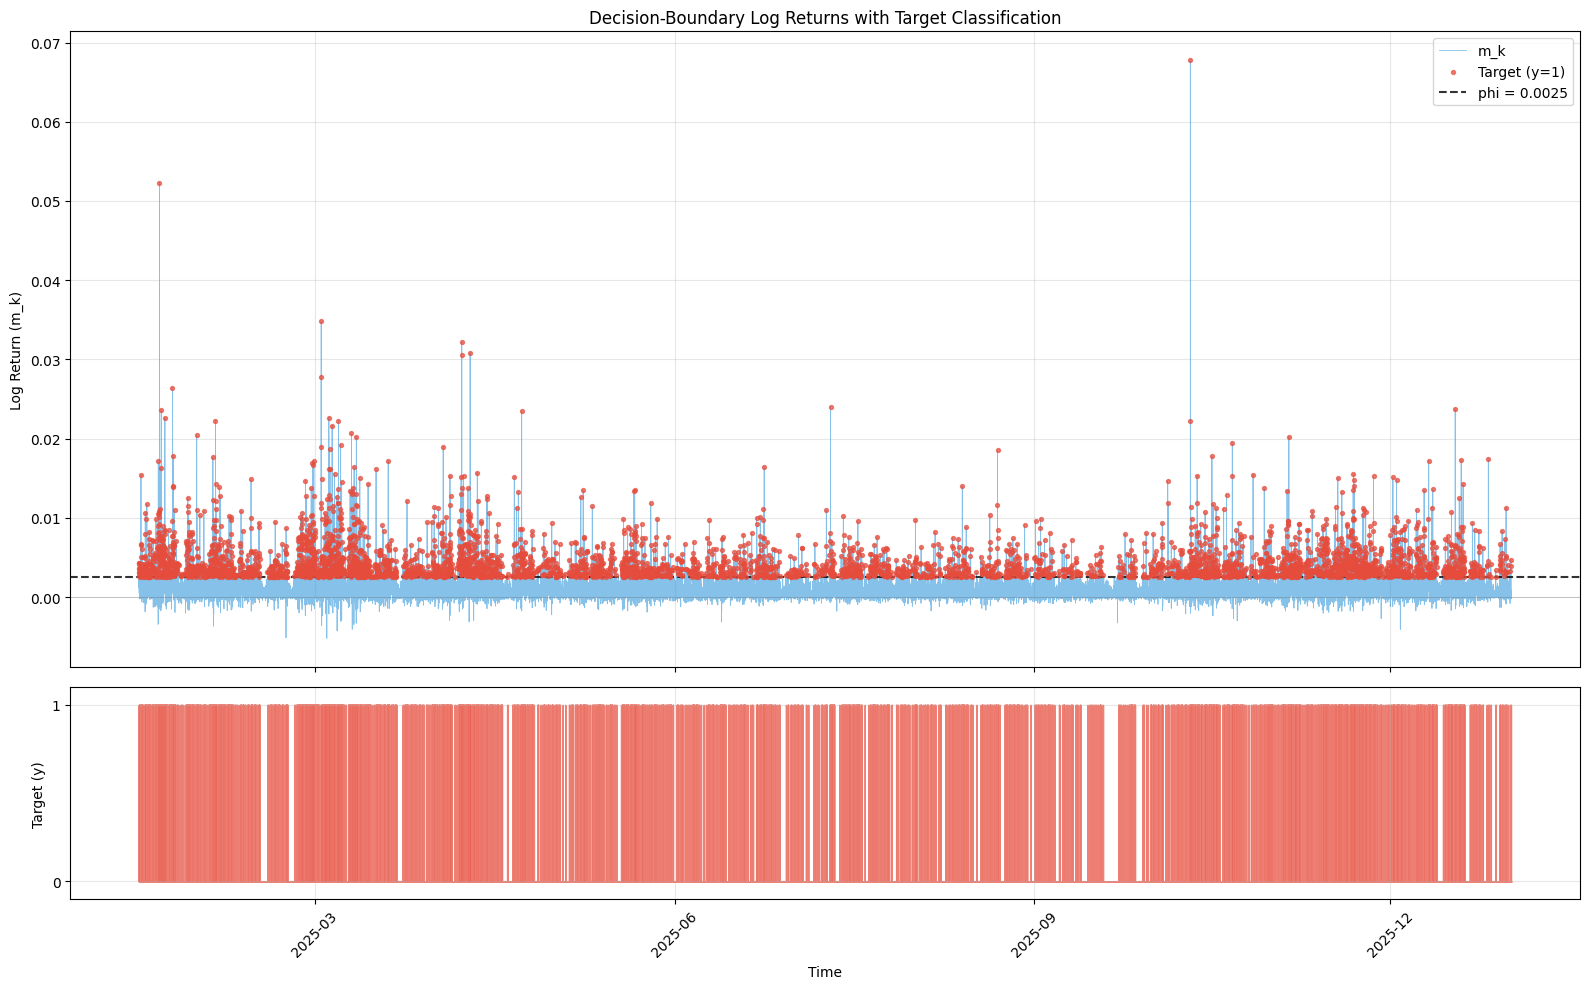


Monthly target distribution:
          hits  total  base_rate
_month                          
2025-01  366.0   1224      0.299
2025-02  467.0   2016      0.232
2025-03  588.0   2232      0.263
2025-04  477.0   2160      0.221
2025-05  360.0   2232      0.161
2025-06  259.0   2160      0.120
2025-07  264.0   2232      0.118
2025-08  242.0   2232      0.108
2025-09  155.0   2160      0.072
2025-10  421.0   2232      0.189
2025-11  532.0   2160      0.246
2025-12  394.0   2231      0.177


C:\Users\vitil\AppData\Local\Temp\ipykernel_20864\557009188.py:64: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_final.assign(_month=pd.to_datetime(df_final['ts']).dt.to_period('M'))


In [20]:
# VISUALIZATION 2: Time series with target markers
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ts = pd.to_datetime(df_final['ts'])
m_k = df_final['m_k'].to_numpy()
y = df_final['y'].to_numpy()
phi = float(df_final['phi'].iloc[0])

fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 10),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]},
)

ax1 = axes[0]
ax1.plot(ts, m_k, color='#3498db', alpha=0.6, linewidth=0.6, label='m_k')

pos_mask = y == 1
ax1.scatter(
    ts[pos_mask],
    m_k[pos_mask],
    color='#e74c3c',
    s=8,
    alpha=0.7,
    label='Target (y=1)',
    zorder=5,
    marker='o',
)

ax1.axhline(
    phi,
    color='black',
    linestyle='--',
    linewidth=1.5,
    alpha=0.8,
    label=f'phi = {phi:.4f}',
)
ax1.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

ax1.set_ylabel('Log Return (m_k)')
ax1.set_title('Decision-Boundary Log Returns with Target Classification')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.fill_between(ts, y, step='mid', alpha=0.7, color='#e74c3c', label='Target (y)')
ax2.set_ylabel('Target (y)')
ax2.set_xlabel('Time')
ax2.set_ylim(-0.1, 1.1)
ax2.set_yticks([0, 1])
ax2.grid(True, alpha=0.3)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

monthly = (
    df_final.assign(_month=pd.to_datetime(df_final['ts']).dt.to_period('M'))
    .groupby('_month')['y']
    .agg(['sum', 'count', 'mean'])
    .round(3)
)
monthly.columns = ['hits', 'total', 'base_rate']
print()
print('Monthly target distribution:')
print(monthly.to_string())
